In [76]:
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
from torchvision import transforms
from torch.utils.data import random_split
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [77]:
class PlantVillage(Dataset):
    def __init__(self, root, transforms=None):
        self.root = Path(root)
        self.transforms = transforms
        self.classes = sorted(c.name for c in self.root.iterdir() if c.is_dir())
        self.IDXclasses = {cls:idx for idx,cls in enumerate(self.classes)}
        self.images = []
        for cls in self.classes:
            class_path = self.root / cls
            for f in sorted(class_path.iterdir()):
                if f.suffix.lower() ==".jpg":
                    self.images.append((f, self.IDXclasses[cls]))
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transforms:
            image = self.transforms(image)
        return image, label

In [78]:
full_data = PlantVillage("PlantVillage")
n = full_data.__len__()
n_train = int(0.7*n)
n_val = int(0.15*n)
n_test = n-n_train-n_val
train_subset, val_subset, test_subset = random_split(
    full_data, 
    [n_train, n_val, n_test],
    generator = torch.Generator().manual_seed(123)
)

In [79]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(0.15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor()
    ])
test_transforms = transforms.Compose([
    transforms.ToTensor()
])

In [80]:
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform =transform
        self.classes = sorted(c.name for c in Path("PlantVillage").iterdir() if c.is_dir())
        self.IDXclasses = {cls:idx for idx,cls in enumerate(self.classes)}
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [81]:
train_data = TransformSubset(train_subset, transform=train_transforms)
val_data = TransformSubset(val_subset, transform=test_transforms)
test_data = TransformSubset(test_subset, transform=test_transforms)

In [82]:
batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size,shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

In [83]:
def show_image(data, idx):
    tensor = data[idx][0]
    label = data.classes[data[idx][1]]
    img = tensor.permute(1,2,0).numpy()
    img = np.clip(img, 0,1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(label)
    plt.show()

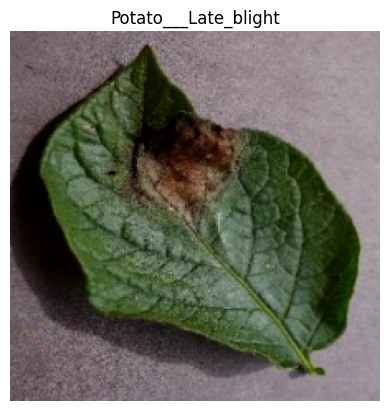

In [90]:
show_image(train_data, 10000)